---
date: "2026-05-11"
date-modified: last-modified
format:
  html:
    toc: true
---

# 1. The Limit of a Sequence

**Definition:** Consider the sequence $\{a_n\}$. We call $L$ the **limit** of the sequence if, for any arbitrarily small positive number $\epsilon$, there exists an integer $N$ such that all terms past $N$ fall within $\epsilon$ of $L$.

Mathematically, this is written as:


$$\forall \epsilon > 0, \exists N \in \mathbb{N} : n \geq N \implies |a_n - L| < \epsilon$$

If such a limit $L$ exists, we say that the sequence $\{a_n\}$ **converges**.

---

# 2. Uniqueness of the Limit

**Theorem:** If a sequence converges, its limit $L$ is unique.

**Proof:**
Assume for the sake of contradiction that $L$ and $L'$ are *both* valid limits of the sequence $\{a_n\}$, and $L \neq L'$.
By the definition of a limit, for any $\epsilon > 0$:

1. $\exists N_1 \in \mathbb{N} : n \geq N_1 \implies |a_n - L| < \epsilon$
2. $\exists N_2 \in \mathbb{N} : n \geq N_2 \implies |a_n - L'| < \epsilon$

We want to satisfy both conditions simultaneously, so we choose $N = \max\{N_1, N_2\}$. For all $n \geq N$, both inequalities hold.
Now, let's set our tolerance to exactly half the distance between the two distinct limits: $\epsilon = \frac{|L - L'|}{2}$.

Using the [Triangle Inequality](triangle-inequality.ipynb), we can write:


$$2\epsilon = |L - L'| = |(L - a_n) + (a_n - L')|$$

$$|L - L'| \leq |L - a_n| + |a_n - L'|$$


Because we are past $N$, we know $|a_n - L| < \epsilon$ and $|a_n - L'| < \epsilon$. Substituting these in gives:


$$|L - L'| < \epsilon + \epsilon = 2\epsilon$$

This leaves us with the statement $2\epsilon < 2\epsilon$, which is a logical contradiction! Therefore, $L$ and $L'$ cannot be different. The limit is unique, and we can definitively write:


$$\lim_{n \to \infty} a_n = L$$


$\square$

---

# 3. Properties and Divergence

**Proposition:** Every convergent sequence is bounded.
*(If a sequence shoots off to infinity, it cannot have a real-number limit).*

**Definition (Divergence to Infinity):** A sequence $\{a_n\}$ is said to diverge to $\infty$ if, for any arbitrarily large number $M$, the sequence eventually surpasses it and stays above it:


$$\forall M \in \mathbb{R}, \exists N \in \mathbb{N} : n \geq N \implies a_n > M$$

### Examples of Convergence and Divergence:

1. **The sequence $\{2^n\}$** converges to $\infty$.
2. **The sequence $\{-n^2\}$** converges to $-\infty$.
3. **The sequence $\{(-1)^n\}$** is strictly bounded (between -1 and 1), but it never settles on a single value, so it diverges without going to $\pm\infty$.

---

# 4. Visualizing the $\epsilon-N$ Definition

To build intuition for the formal limit definition, the Python block below plots a convergent sequence and visually demonstrates the "$\epsilon$ band". Once $n$ passes the threshold $N$, the sequence is permanently trapped inside the band.

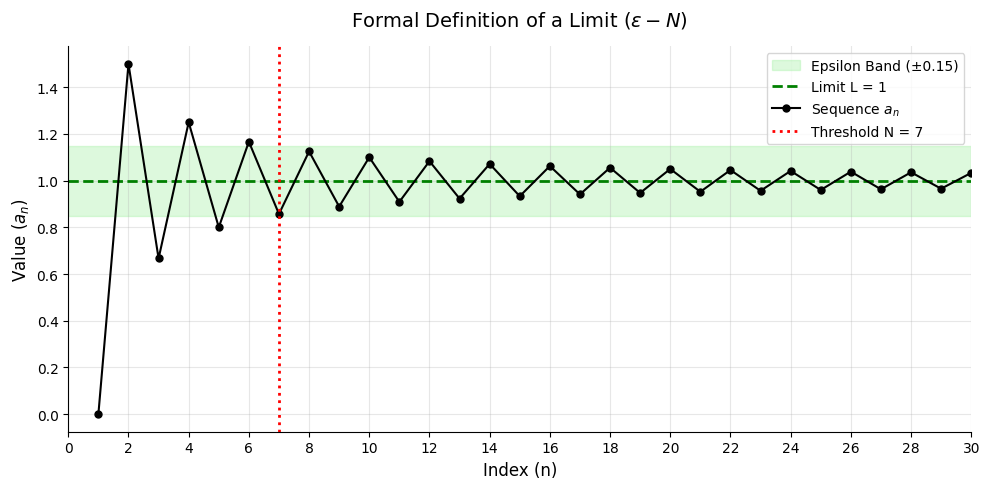

In [1]:
#| label: fig-sequence-limit
#| fig-cap: "Visualization of sequence convergence. All terms after N are trapped within the epsilon band around L."
#| echo: true

import matplotlib.pyplot as plt
import numpy as np

# Define a converging sequence: a_n = 1 + (-1)^n / n
n = np.arange(1, 31)
a_n = 1 + ((-1)**n) / n

# Limit parameters
L = 1
epsilon = 0.15
N_threshold = int(np.ceil(1 / epsilon)) # Threshold where |a_n - L| < epsilon

fig, ax = plt.subplots(figsize=(10, 5))

# Plot the epsilon band
ax.axhspan(L - epsilon, L + epsilon, color='lightgreen', alpha=0.3, label=f'Epsilon Band (±{epsilon})')
ax.axhline(L, color='green', linestyle='dashed', lw=2, label='Limit L = 1')

# Plot the sequence
ax.plot(n, a_n, 'ko-', markersize=5, label=r'Sequence $a_n$')

# Highlight the threshold N
ax.axvline(N_threshold, color='red', linestyle='dotted', lw=2, label=f'Threshold N = {N_threshold}')

# Formatting
ax.set_title(r"Formal Definition of a Limit ($\epsilon-N$)", pad=15, fontsize=14)
ax.set_xlabel("Index (n)", fontsize=12)
ax.set_ylabel(r"Value ($a_n$)", fontsize=12)
ax.set_xlim(0, 30)
ax.set_xticks(np.arange(0, 31, 2))
ax.grid(alpha=0.3)
ax.legend(loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()